In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('data/Train.csv')
test = pd.read_csv('data/Test.csv')
monomers = pd.read_csv('data/CycPeptMPDB_Monomer_All (2).csv')

In [3]:
all_residues = sorted(set(mono for mono in monomers['Symbol']))
print("List of all residues used:")
print(sorted(all_residues))

List of all residues used:
['(N->O)Leu', '(N->O)Tyr', '(N->O)Val', '(N->O)Val(3-OH)', '(N->O)xiIle', '-aze', '-mor', '-nme2', '-pip', '-pyrro', '1-Nal', '2-pyridylmethyl_Gly', '2Abz', '3-pyridylethyl_Gly', '3Pal', '4Pal', '5-Ava', 'A', 'Abu', 'Abu(5-Tet)', 'Ac3c', 'Ac5c', 'Aib', 'Ala(5-Tet)', 'Ala(O->S)', 'Ala(cBu)', 'Ala(cPent)', 'Ala(cPr)', 'Ala(indol-2-yl)', 'Ala(tBu)', 'Aoc(2)', 'Arg(Me,Me)', 'Asp(OMe)', 'Asp(Ph(2-NH2))', 'Asp_piperidide', 'Aze', 'Bal', 'Bal(3-Me)', 'Bal(d3-CF3)', 'Bal(d3-EtPh)', 'Bal(d3-Me)', 'Bn(4-Cl)_Gly', 'Bn(4-OH)_Gly', 'Bn_Gly', 'Bu_Gly', 'Cha', 'Chg', 'Cys(EtO2H)_NH2', 'D', 'E', 'EtOEt_Gly', 'Et_Gly', 'Et_Leu', 'Et_Phe', 'Et_Phe(4-Me)', 'F', 'G', 'GABA', 'Gln(Me)', 'Gln(Me2)', 'Gln(Mes)', 'Glu(3R-Me)', 'Glu(OMe)', 'Glu_NH2', 'Gly(allyl)', 'Gly(cBu)', 'Gly(cPent)', 'Gly(cPr)', 'H', 'H2NEt_Phe', 'HOCOCH2_Bal', 'HOCOCH2_Gly_ol', 'Hch', 'Hph', 'Hph(2-Cl)', 'Hph(3,4-diCl)', 'Hph(3-Cl)', 'Hph(4-CF3)', 'Hph(4-CF3,3,5-diF)', 'Hph(4-CF3,3-Cl)', 'Hph(4-Cl)', 'Hph(4-Me

In [4]:
for res in all_residues:
    if len(res) == 1 or len(res) == 2:
        print(str(res))
        # print(type(res))

A
D
E
F
G
H
I
K
L
M
N
P
Q
R
S
T
V
W
Y
dA
dF
dI
dK
dL
dN
dP
dR
dS
dT
dV
dW
dY


In [5]:
combined_df = pd.concat([train, test], axis=0, ignore_index=True)

In [6]:
type(combined_df['Sequence'][0])

str

In [7]:
combined_df

,ID,SMILES,Permeability,Sequence,MolWt
0,915,CC[C@H](C)[C@H](NC(=O)[C@@H]1CC(=O)N[C@@H](Cc2...,-7.00,"['F', 'meL', 'A', 'meL', 'Ser(tBu)', 'meL', 'm...",1773.325
1,888,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1cccc(Cl)c1)N(C)...,-7.00,"['F', 'meF', 'P', 'L', 'Me_Phe(3-Cl)', 'T', 'L...",1745.057
2,593,C/N=C(\NC)NCCC[C@@H]1NC(=O)[C@H](Cc2ccccc2)N(C...,-7.00,"['Sar', 'F', 'meL', 'meL', 'F', 'meL', 'L', 'm...",1733.267
3,916,CC[C@H](C)[C@H](NC(=O)[C@@H](NC(=O)[C@@H]1CC(=...,-7.00,"['Me_Bal', 'F', 'meF', 'meL', 'T', 'meA', 'meL...",1725.281
4,900,CC[C@H](C)[C@H](NC(=O)[C@H](Cc1ccccc1)N(C)C(=O...,-7.00,"['meA', 'meL', 'meF', 'T', 'meL', 'meL', 'I', ...",1723.309
...,...,...,...,...,...
6955,2481,CC(C)C[C@H]1NC(=O)[C@H](C)NC(=O)[C@H](Cc2ccccc...,-4.50,"['A', 'dL', 'Mono78']",430.593
6956,2485,CC(C)C[C@H]1NC(=O)[C@H](C)NC(=O)[C@@H](Cc2cccc...,-4.80,"['A', 'dL', 'Mono87']",430.593
6957,5604,CC(C)CN1CC(=O)N[C@@H](Cc2ccccc2)C(=O)NCCCCC(=O...,-6.38,"['A', 'iBu_Gly', 'F', '5-Ava']",430.549
6958,2513,C[C@H]1NCCCCCCNC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[...,-7.80,"['P', 'Y', 'Mono85']",430.549


In [8]:
import ast

def safe_parse(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x

combined_df['Sequence'] = combined_df['Sequence'].apply(safe_parse)

In [9]:
natural_aa = ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I',  'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']
d_type_aa =[f'd{aa}' for aa in natural_aa]

print(d_type_aa)

['dA', 'dR', 'dN', 'dD', 'dC', 'dE', 'dQ', 'dG', 'dH', 'dI', 'dL', 'dK', 'dM', 'dF', 'dP', 'dS', 'dT', 'dW', 'dY', 'dV']


In [10]:
def is_natural(seq):
    return all(residue in natural_aa for residue in seq)

def has_d_amino(seq):
    return any(str(res) in d_type_aa for res in seq)

In [11]:
combined_df['is_natural'] = combined_df['Sequence'].apply(is_natural)

In [12]:
num_natural_peptides = combined_df['is_natural'].sum()
print("num_natural_peptides",num_natural_peptides)

num_natural_peptides 14


In [13]:
combined_df['has_d_amino'] = combined_df['Sequence'].apply(has_d_amino)
num_with_d = combined_df['has_d_amino'].sum()
print(num_with_d)


5365


In [14]:
aa_train = pd.read_csv('features/Monomeric/Train_aac.csv')
aa_test = pd.read_csv('features/Monomeric/Test_aac.csv')
aa_df = pd.concat([aa_train, aa_test], axis=0, ignore_index=True)
aa_df['Label'] = aa_df['Permeability'].apply(lambda x: 1 if x >= -6 else 0)
label_counts = aa_df['Label'].value_counts().sort_index()
print("Number of peptides by permeability class:")
print(f"Non-permeable (Label 0): {label_counts[0]}")
print(f"Permeable     (Label 1): {label_counts[1]}")

aa_columns = ['A', 'R', 'N', 'D', 'C',
              'E', 'Q', 'G', 'H', 'I',
              'L', 'K', 'M', 'F', 'P',
              'S', 'T', 'W', 'Y', 'V', 'X']

average_composition = aa_df.groupby('Label')[aa_columns].mean()*100

print("Average amino acid composition across peptides:")
print(average_composition)

Number of peptides by permeability class:
Non-permeable (Label 0): 2151
Permeable     (Label 1): 4809
Average amino acid composition across peptides:
               A         R         N         D         C         E         Q  \
Label                                                                          
0      13.334302  0.060658  0.024795  0.258645  0.789223  0.024795  0.281335   
1      11.636695  0.026850  0.033271  1.154874  0.213390  0.012195  0.083871   

              G         H         I  ...         K         M          F  \
Label                                ...                                  
0      9.614533  0.024718  0.757979  ...  0.037669  0.035771   9.001424   
1      8.237835  0.007838  1.042209  ...  0.101675  0.007376  13.801136   

               P         S         T         W         Y         V         X  
Label                                                                         
0      18.832026  0.105030  3.192862  0.048040  0.684842  1.401190  4.

<Figure size 1200x600 with 0 Axes>

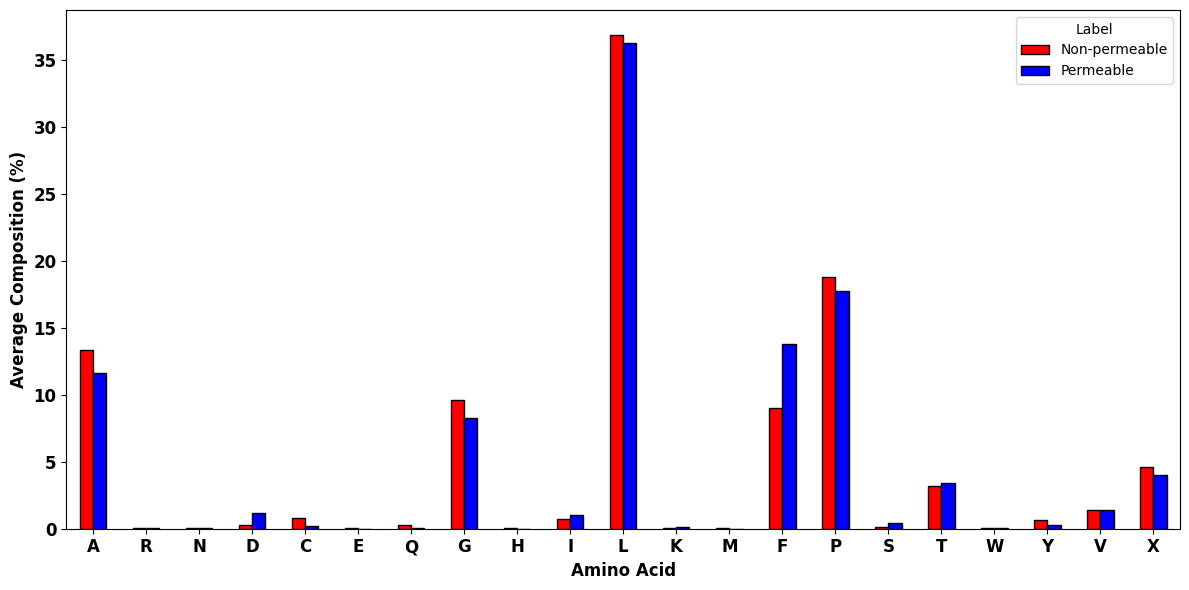

In [15]:
avg_comp_df = average_composition.T
avg_comp_df.columns = ['Non-permeable', 'Permeable']
avg_comp_df = avg_comp_df.reset_index().rename(columns={'index': 'Amino Acid'})

# Plot
plt.figure(figsize=(12, 6))
avg_comp_df.set_index('Amino Acid').plot(
    kind='bar',
    figsize=(12, 6),
    color=['red', 'blue'],
    edgecolor='black'
)

plt.xlabel("Amino Acid", fontsize=12, fontweight='bold')
plt.ylabel("Average Composition (%)", fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontweight='bold', fontsize=12)
plt.yticks(fontweight='bold', fontsize=12)
plt.legend(title="Label")
plt.tight_layout()
plt.savefig("/home/users/akshay/PCPpred/PAMPA/average_amino_acid_composition.png", dpi=600)
plt.show()

In [16]:
m_train = pd.read_csv('features/Monomeric/Train_mon_comp.csv')
m_test = pd.read_csv('features/Monomeric/Test_mon_comp.csv')
m_df = pd.concat([m_train, m_test], axis=0, ignore_index=True)
m_df['Label'] = m_df['Permeability'].apply(lambda x: 1 if x > -6 else 0)

average_mono_composition = m_df.groupby('Label')[all_residues].mean() * 100
average_mono_composition = average_mono_composition.round(3)
average_mono_composition

,(N->O)Leu,(N->O)Tyr,(N->O)Val,(N->O)Val(3-OH),(N->O)xiIle,-aze,-mor,-nme2,-pip,-pyrro,...,meM,meN,meQ,meS,meT,meV,meW,meY,medl-,pentyl_Gly
Label,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.000,0.000,0.000,0.005,0.0,0.0,0.0,0.317,0.0,...,0.005,0.000,0.009,0.007,0.075,0.104,0.0,0.113,0.000,0.271
1,0.017,0.003,0.003,0.003,0.000,0.0,0.0,0.0,1.263,0.0,...,0.000,0.004,0.000,0.037,0.010,0.510,0.0,0.103,0.003,0.348


<Figure size 1400x700 with 0 Axes>

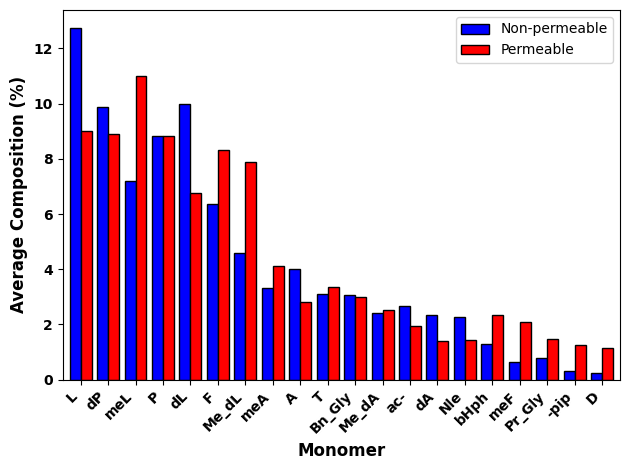

In [17]:
overall_mean = average_mono_composition.mean()
top_n = 20
top_monomers = overall_mean.sort_values(ascending=False).head(top_n).index

# Filter and reorder dataframe to plot
plot_df = average_mono_composition[top_monomers].transpose()

# Plot
plt.figure(figsize=(14, 7))
plot_df.plot(kind='bar', color=['blue', 'red'], edgecolor='black', width=0.8)

plt.xlabel("Monomer", fontsize=12, fontweight='bold')
plt.ylabel("Average Composition (%)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(fontweight='bold', fontsize=10)
plt.legend(['Non-permeable', 'Permeable'], fontsize=10)
plt.tight_layout()

# Save and show
plt.savefig(f"/home/users/akshay/PCPpred/PAMPA/top_{top_n}_monomer_composition_combined.png", dpi=600)
plt.show()

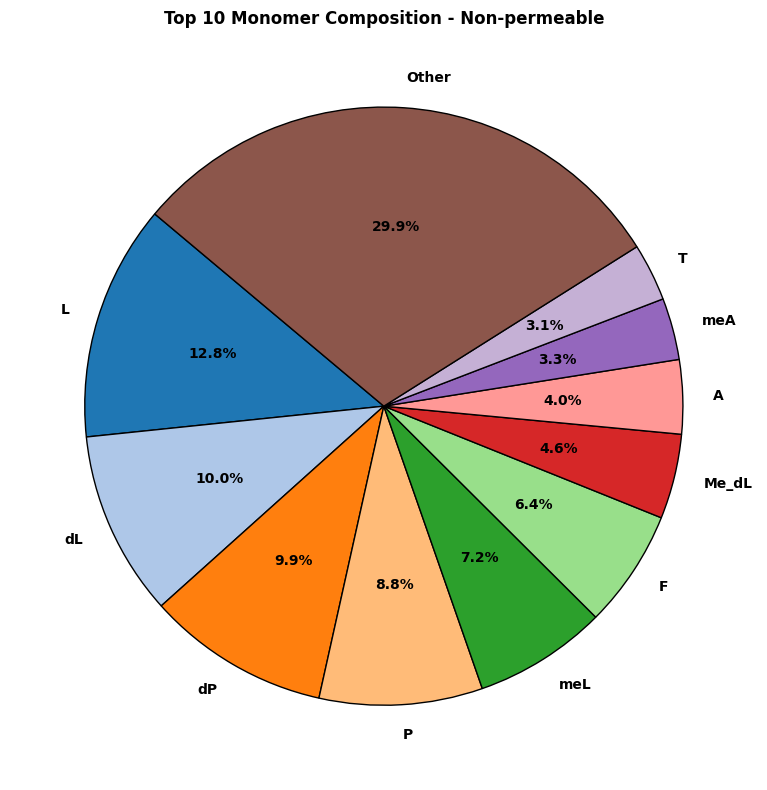

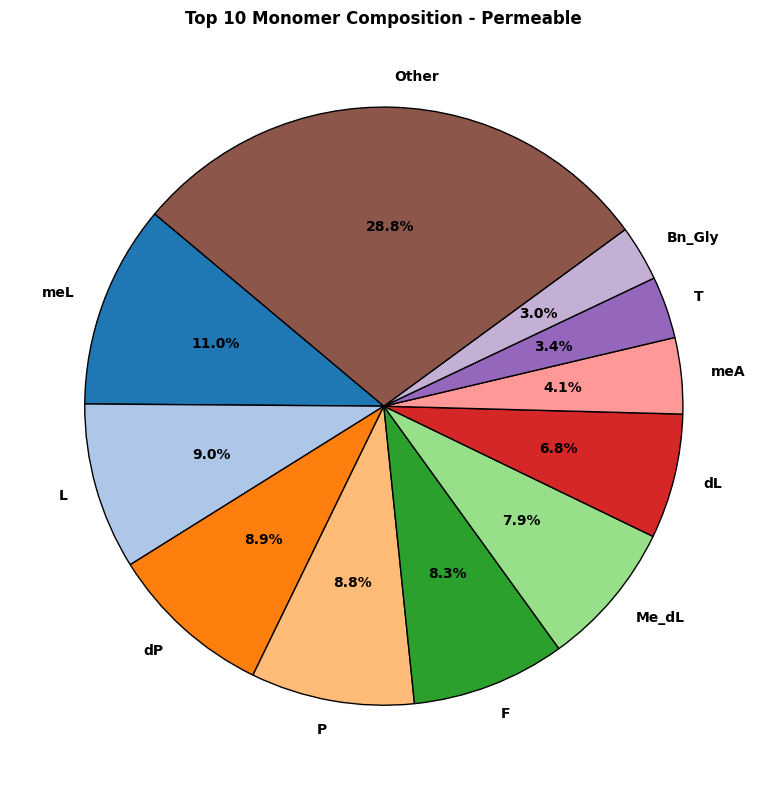

In [18]:
top_n = 10
colors = plt.cm.tab20.colors

for label in [0, 1]:
    sorted_monomers = average_mono_composition.loc[label].sort_values(ascending=False)
    top_monomers = sorted_monomers.head(top_n)
    other_sum = sorted_monomers.iloc[top_n:].sum()

    pie_data = top_monomers.copy()
    pie_data['Other'] = other_sum

    plt.figure(figsize=(8, 8))
    pie_data.plot(
        kind='pie',
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'black'},
        fontsize=10,
        textprops={'fontweight': 'bold'}
    )
    label_name = "Non-permeable" if label == 0 else "Permeable"
    plt.title(f"Top {top_n} Monomer Composition - {label_name}", fontweight='bold')
    plt.ylabel('')  
    plt.tight_layout()
    plt.savefig(f"/home/users/akshay/PCPpred/PAMPA/monomer_composition_pie_chart_label_{label}.png", dpi=300)
    plt.show()


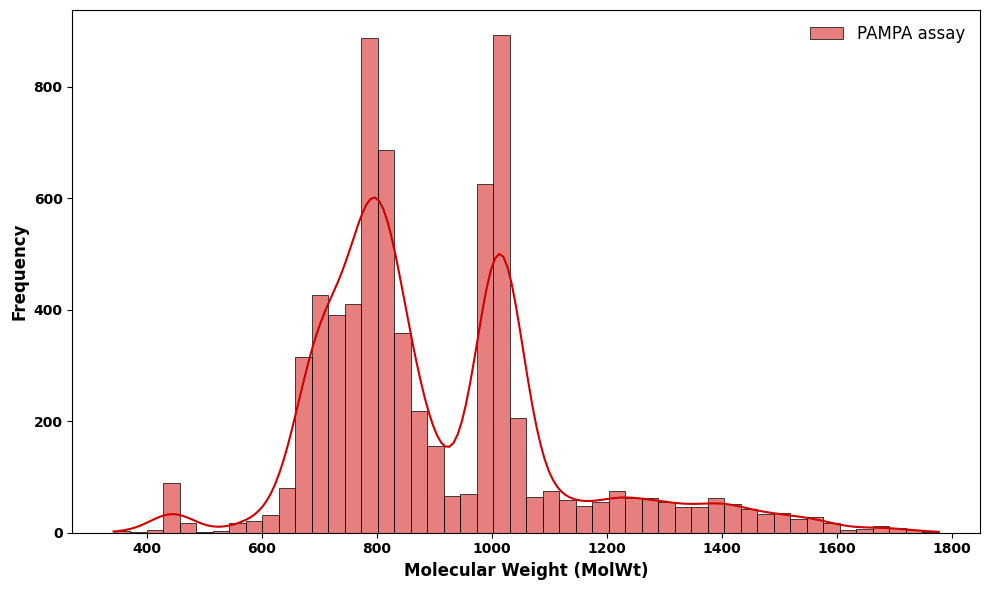

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['MolWt'], bins=50, kde=True, color="#D00000", edgecolor='black', linewidth=0.5, label='PAMPA assay')

plt.xlabel('Molecular Weight (MolWt)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.legend(title='', fontsize=12, loc='upper right', frameon=False)
plt.tight_layout()

plt.savefig("/home/users/akshay/PCPpred/PAMPA/molwt_distribution_pampa.png", dpi=600)
plt.show()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import itertools
import math

In [21]:
m_train = pd.read_csv('features/Monomeric/Train_mon_comp.csv')
m_test = pd.read_csv('features/Monomeric/Test_mon_comp.csv')
m_df = pd.concat([m_train, m_test], axis=0, ignore_index=True)

monomer_cols = [col for col in m_df.columns if col not in ["Permeability","SMILES","ID"]]
monomer_means = m_df[monomer_cols].mean().sort_values(ascending=False)
top_10_monomers = monomer_means.head(10).index.tolist()
print(top_10_monomers)

pdf_filename = "single_monomer_boxplots_pampa.pdf"
with PdfPages(pdf_filename) as pdf:
    fig, axes = plt.subplots(5, 2, figsize=(20, 28), sharey=True)  # Bigger plots
    axes = axes.flatten()

    for i, monomer in enumerate(top_10_monomers):
        df_with = m_df[m_df[monomer] > 0].copy()
        df_without = m_df[m_df[monomer] == 0].copy()
        df_with["Group"] = "With"
        df_without["Group"] = "Without"
        df_combined = pd.concat([df_with, df_without], axis=0)

        sns.boxplot(data=df_combined, x="Group", y="Permeability", 
                    palette="Set2", width=0.5, ax=axes[i])
        sns.stripplot(data=df_combined, x="Group", y="Permeability", 
                      color="black", alpha=0.4, jitter=True, size=3, ax=axes[i])

        axes[i].set_title(f"{monomer}", fontsize=16)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Permeability", fontsize=14)
        axes[i].tick_params(axis="x", labelsize=12)
        axes[i].tick_params(axis="y", labelsize=12)

    for j in range(len(top_10_monomers), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    pdf.savefig(fig)  
    plt.close(fig)

print(f"Saved: {pdf_filename}")


['L', 'meL', 'dP', 'P', 'dL', 'F', 'Me_dL', 'meA', 'T', 'A']


/tmp/ipykernel_3945542/2107004199.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/2107004199.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/2107004199.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/2107004199.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

Saved: single_monomer_boxplots_pampa.pdf


In [22]:
monomer_pairs = list(itertools.combinations(top_10_monomers, 2))

pdf_filename = "pairwise_monomer_boxplots_pampa.pdf"
plots_per_page = 9  
n_pages = math.ceil(len(monomer_pairs) / plots_per_page)

with PdfPages(pdf_filename) as pdf:
    for page in range(n_pages):
        fig, axes = plt.subplots(3, 3, figsize=(24, 18), sharey=True)  # BIG plots
        axes = axes.flatten()

        start = page * plots_per_page
        end = min(start + plots_per_page, len(monomer_pairs))
        pairs = monomer_pairs[start:end]

        for ax, (m1, m2) in zip(axes, pairs):
            df_with = m_df[(m_df[m1] > 0) & (m_df[m2] > 0)].copy()
            df_with["Group"] = f"With {m1}+{m2}"

            df_without = m_df[~((m_df[m1] > 0) & (m_df[m2] > 0))].copy()
            df_without["Group"] = f"Without {m1}+{m2}"

            df_combined = pd.concat([df_with, df_without], axis=0)

            if df_with.empty or df_without.empty:
                ax.axis("off")
                continue

            sns.boxplot(data=df_combined, x="Group", y="Permeability",
                        palette="Set2", width=0.6, ax=ax)
            sns.stripplot(data=df_combined, x="Group", y="Permeability",
                          color="black", alpha=0.4, jitter=True, size=3, ax=ax)

            ax.set_title(f"{m1} + {m2}", fontsize=16)
            ax.set_xlabel("")
            ax.set_ylabel("Permeability", fontsize=14)

        for i in range(len(pairs), len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"✅ Saved: {pdf_filename}")

/tmp/ipykernel_3945542/111433499.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/111433499.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/111433499.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/111433499.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Ass

✅ Saved: pairwise_monomer_boxplots_pampa.pdf


In [23]:
monomer_triples = list(itertools.combinations(top_10_monomers, 3))

pdf_filename = "triple_monomer_boxplots_pampa.pdf"
plots_per_page = 9  
n_pages = math.ceil(len(monomer_triples) / plots_per_page)

with PdfPages(pdf_filename) as pdf:
    for page in range(n_pages):
        fig, axes = plt.subplots(3, 3, figsize=(24, 18), sharey=True)  # BIG plots
        axes = axes.flatten()

        start = page * plots_per_page
        end = min(start + plots_per_page, len(monomer_triples))
        combos = monomer_triples[start:end]

        for ax, (m1, m2, m3) in zip(axes, combos):
           
            df_with = m_df[(m_df[m1] > 0) & (m_df[m2] > 0) & (m_df[m3] > 0)].copy()
            df_with["Group"] = f"With {m1}+{m2}+{m3}"

            df_without = m_df[~((m_df[m1] > 0) & (m_df[m2] > 0) & (m_df[m3] > 0))].copy()
            df_without["Group"] = f"Without {m1}+{m2}+{m3}"

            df_combined = pd.concat([df_with, df_without], axis=0)

            if df_with.empty or df_without.empty:
                ax.axis("off")
                continue

            sns.boxplot(data=df_combined, x="Group", y="Permeability",
                        palette="Set2", width=0.6, ax=ax)
            sns.stripplot(data=df_combined, x="Group", y="Permeability",
                          color="black", alpha=0.4, jitter=True, size=3, ax=ax)

            ax.set_title(f"{m1} + {m2} + {m3}", fontsize=18)
            ax.set_xlabel("")
            ax.set_ylabel("Permeability", fontsize=14)

        for i in range(len(combos), len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"✅ Saved:{pdf_filename}")

/tmp/ipykernel_3945542/1876808582.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/1876808582.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/1876808582.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/1876808582.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

✅ Saved:triple_monomer_boxplots_pampa.pdf


In [32]:
#Modified amino acid residues (monomers)
m_train = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Monomeric/Train_mon_comp.csv')
m_test = pd.read_csv('/home/users/akshay/PCPpred/PAMPA/features/Monomeric/Test_mon_comp.csv')
m_df = pd.concat([m_train, m_test], axis=0, ignore_index=True)

standard_aas = {
    "A", "R", "N", "D", "C", "E", "Q", "G", "H", 
    "I", "L", "K", "M", "F", "P", "S", "T", "W", 
    "Y", "V"
}

monomer_cols = [col for col in m_df.columns if col not in ["Permeability", "SMILES", "ID"]]
non_aa_monomers = [col for col in monomer_cols if col not in standard_aas]

monomer_means = m_df[non_aa_monomers].mean().sort_values(ascending=False)

top_10_monomers = monomer_means.head(10).index.tolist()
print(top_10_monomers) 
pdf_filename = "single_non_classical_monomer_boxplots_pampa.pdf"
with PdfPages(pdf_filename) as pdf:
    fig, axes = plt.subplots(5, 2, figsize=(20, 28), sharey=True)  # Bigger plots
    axes = axes.flatten()

    for i, monomer in enumerate(top_10_monomers):
        df_with = m_df[m_df[monomer] > 0].copy()
        df_without = m_df[m_df[monomer] == 0].copy()
        df_with["Group"] = "With"
        df_without["Group"] = "Without"
        df_combined = pd.concat([df_with, df_without], axis=0)

        sns.boxplot(data=df_combined, x="Group", y="Permeability", 
                    palette="Set2", width=0.5, ax=axes[i])
        sns.stripplot(data=df_combined, x="Group", y="Permeability", 
                      color="black", alpha=0.4, jitter=True, size=3, ax=axes[i])

        axes[i].set_title(f"{monomer}", fontsize=16)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Permeability", fontsize=14)
        axes[i].tick_params(axis="x", labelsize=12)
        axes[i].tick_params(axis="y", labelsize=12)

    for j in range(len(top_10_monomers), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    pdf.savefig(fig)  
    plt.close(fig)

print(f"Saved: {pdf_filename}")

['meL', 'dP', 'dL', 'Me_dL', 'meA', 'Bn_Gly', 'Me_dA', 'ac-', 'bHph', 'Nle']


/tmp/ipykernel_3945542/717451969.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/717451969.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/717451969.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/717451969.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Ass

Saved: single_non_classical_monomer_boxplots_pampa.pdf


In [33]:
png_filename = "single_non_classical_monomer_boxplots_pampa.png"

fig, axes = plt.subplots(2, 5, figsize=(28, 12), sharey=True)  # wider for 5 columns
axes = axes.flatten()

for i, monomer in enumerate(top_10_monomers):
    df_with = m_df[m_df[monomer] > 0].copy()
    df_without = m_df[m_df[monomer] == 0].copy()
    df_with["Group"] = "With"
    df_without["Group"] = "Without"
    df_combined = pd.concat([df_with, df_without], axis=0)

    sns.boxplot(data=df_combined, x="Group", y="Permeability",
                palette="Set2", width=0.5, ax=axes[i])
    sns.stripplot(data=df_combined, x="Group", y="Permeability",
                  color="black", alpha=0.4, jitter=True, size=3, ax=axes[i])

    axes[i].set_title(f"{monomer}", fontsize=18, weight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Permeability", fontsize=14)
    axes[i].tick_params(axis="x", labelsize=12)
    axes[i].tick_params(axis="y", labelsize=12)

for j in range(len(top_10_monomers), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(png_filename, dpi=600, bbox_inches="tight") 
plt.close()

print(f"Saved: {png_filename}")

/tmp/ipykernel_3945542/2980501623.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/2980501623.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/2980501623.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/2980501623.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

Saved: single_non_classical_monomer_boxplots_pampa.png


In [34]:
monomer_pairs = list(itertools.combinations(top_10_monomers, 2))

pdf_filename = "pairwise_non_classical_monomer_boxplots_pampa.pdf"
plots_per_page = 9  
n_pages = math.ceil(len(monomer_pairs) / plots_per_page)

with PdfPages(pdf_filename) as pdf:
    for page in range(n_pages):
        fig, axes = plt.subplots(3, 3, figsize=(24, 18), sharey=True)  # BIG plots
        axes = axes.flatten()

        start = page * plots_per_page
        end = min(start + plots_per_page, len(monomer_pairs))
        pairs = monomer_pairs[start:end]

        for ax, (m1, m2) in zip(axes, pairs):
            df_with = m_df[(m_df[m1] > 0) & (m_df[m2] > 0)].copy()
            df_with["Group"] = f"With {m1}+{m2}"

            df_without = m_df[~((m_df[m1] > 0) & (m_df[m2] > 0))].copy()
            df_without["Group"] = f"Without {m1}+{m2}"

            df_combined = pd.concat([df_with, df_without], axis=0)

            if df_with.empty or df_without.empty:
                ax.axis("off")
                continue

            sns.boxplot(data=df_combined, x="Group", y="Permeability",
                        palette="Set2", width=0.6, ax=ax)
            sns.stripplot(data=df_combined, x="Group", y="Permeability",
                          color="black", alpha=0.4, jitter=True, size=3, ax=ax)

            ax.set_title(f"{m1} + {m2}", fontsize=16)
            ax.set_xlabel("")
            ax.set_ylabel("Permeability", fontsize=14)

        for i in range(len(pairs), len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"✅ Saved: {pdf_filename}")

/tmp/ipykernel_3945542/1550582602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/1550582602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/1550582602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/1550582602.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

✅ Saved: pairwise_non_classical_monomer_boxplots_pampa.pdf


In [35]:
monomer_triples = list(itertools.combinations(top_10_monomers, 3))

pdf_filename = "triple_non_classical_monomer_boxplots_pampa.pdf"
plots_per_page = 9  
n_pages = math.ceil(len(monomer_triples) / plots_per_page)

with PdfPages(pdf_filename) as pdf:
    for page in range(n_pages):
        fig, axes = plt.subplots(3, 3, figsize=(24, 18), sharey=True)  # BIG plots
        axes = axes.flatten()

        start = page * plots_per_page
        end = min(start + plots_per_page, len(monomer_triples))
        combos = monomer_triples[start:end]

        for ax, (m1, m2, m3) in zip(axes, combos):
           
            df_with = m_df[(m_df[m1] > 0) & (m_df[m2] > 0) & (m_df[m3] > 0)].copy()
            df_with["Group"] = f"With {m1}+{m2}+{m3}"

            df_without = m_df[~((m_df[m1] > 0) & (m_df[m2] > 0) & (m_df[m3] > 0))].copy()
            df_without["Group"] = f"Without {m1}+{m2}+{m3}"

            df_combined = pd.concat([df_with, df_without], axis=0)

            if df_with.empty or df_without.empty:
                ax.axis("off")
                continue

            sns.boxplot(data=df_combined, x="Group", y="Permeability",
                        palette="Set2", width=0.6, ax=ax)
            sns.stripplot(data=df_combined, x="Group", y="Permeability",
                          color="black", alpha=0.4, jitter=True, size=3, ax=ax)

            ax.set_title(f"{m1} + {m2} + {m3}", fontsize=18)
            ax.set_xlabel("")
            ax.set_ylabel("Permeability", fontsize=14)

        for i in range(len(combos), len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"✅ Saved:{pdf_filename}")

/tmp/ipykernel_3945542/3274122501.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/3274122501.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/3274122501.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x="Group", y="Permeability",
/tmp/ipykernel_3945542/3274122501.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0.

✅ Saved:triple_non_classical_monomer_boxplots_pampa.pdf


In [47]:
#Molecular weight based analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

In [48]:
df = pd.read_csv('data/CycPeptMPDB_data_Main.csv')
df = df[["MolWt","Permeability"]]
df

,MolWt,Permeability
0,712.933,-7.000000
1,712.933,-7.100000
2,712.933,-7.300000
3,712.933,-7.300000
4,712.933,-7.300000
...,...,...
6955,1091.454,-5.929053
6956,1051.389,-6.566211
6957,1065.416,-6.199359
6958,553.664,-6.780000


In [49]:
pearson_corr, pval_pearson = pearsonr(df["MolWt"], df["Permeability"])
spearman_corr, pval_spearman = spearmanr(df["MolWt"], df["Permeability"])

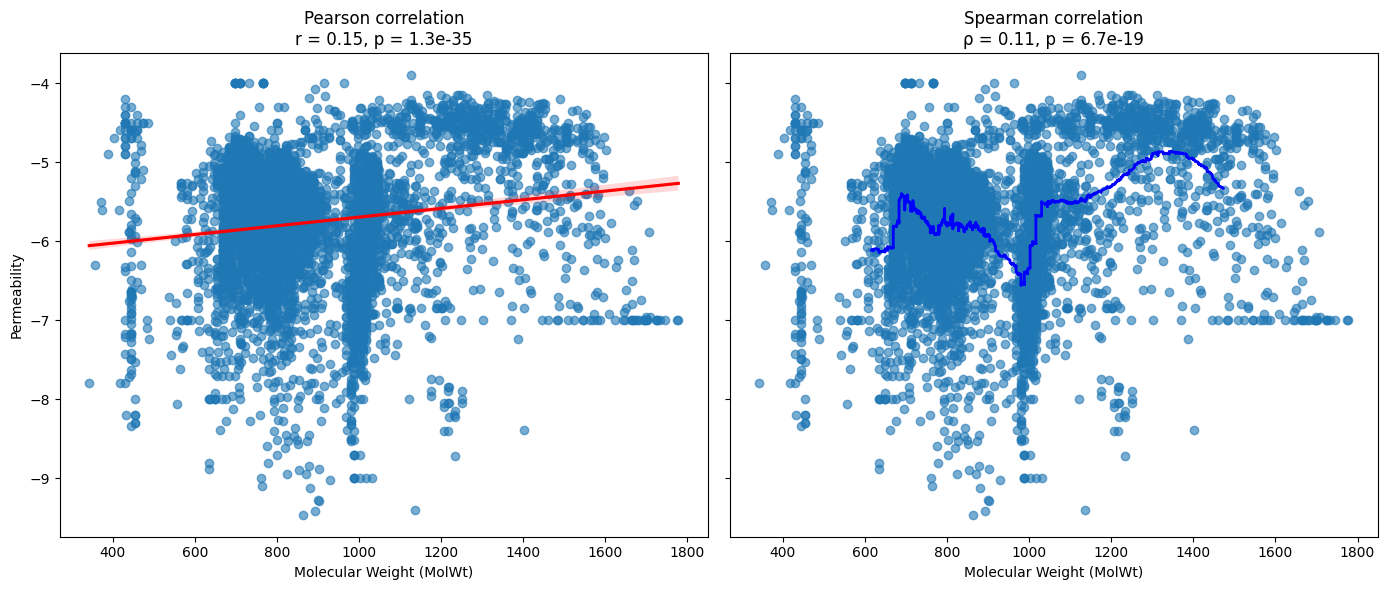

In [50]:
df_sorted = df.sort_values("MolWt").reset_index(drop=True)
window = max(5, len(df)//20)  
df_sorted["smooth_perm"] = df_sorted["Permeability"].rolling(window=window, center=True).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Pearson (linear regression line)
sns.regplot(
    x="MolWt", y="Permeability", data=df,
    scatter_kws={"alpha":0.6}, line_kws={"color":"red"},
    ax=axes[0]
)
axes[0].set_title(f"Pearson correlation\nr = {pearson_corr:.2f}, p = {pval_pearson:.1e}")
axes[0].set_xlabel("Molecular Weight (MolWt)")
axes[0].set_ylabel("Permeability")

# Spearman (rolling mean as trend)
axes[1].scatter(df_sorted["MolWt"], df_sorted["Permeability"], alpha=0.6)
axes[1].plot(df_sorted["MolWt"], df_sorted["smooth_perm"], color="blue", linewidth=2)
axes[1].set_title(f"Spearman correlation\nρ = {spearman_corr:.2f}, p = {pval_spearman:.1e}")
axes[1].set_xlabel("Molecular Weight (MolWt)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("MolWt_vs_Permeability_Correlations.png", dpi=600, bbox_inches="tight")
plt.show()

In [51]:
plt.figure(figsize=(7, 6))
sns.regplot(
    x="MolWt", y="Permeability", data=df,
    scatter_kws={"alpha": 0.6}, line_kws={"color": "red"}
)
plt.title(f"Pearson correlation\nr = {pearson_corr:.2f}, p = {pval_pearson:.1e}")
plt.xlabel("Molecular Weight (MolWt)")
plt.ylabel("Permeability")
plt.tight_layout()
plt.savefig("MolWt_vs_Permeability_Pearson.png", dpi=600, bbox_inches="tight")
plt.close()

/tmp/ipykernel_3945542/2559517772.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


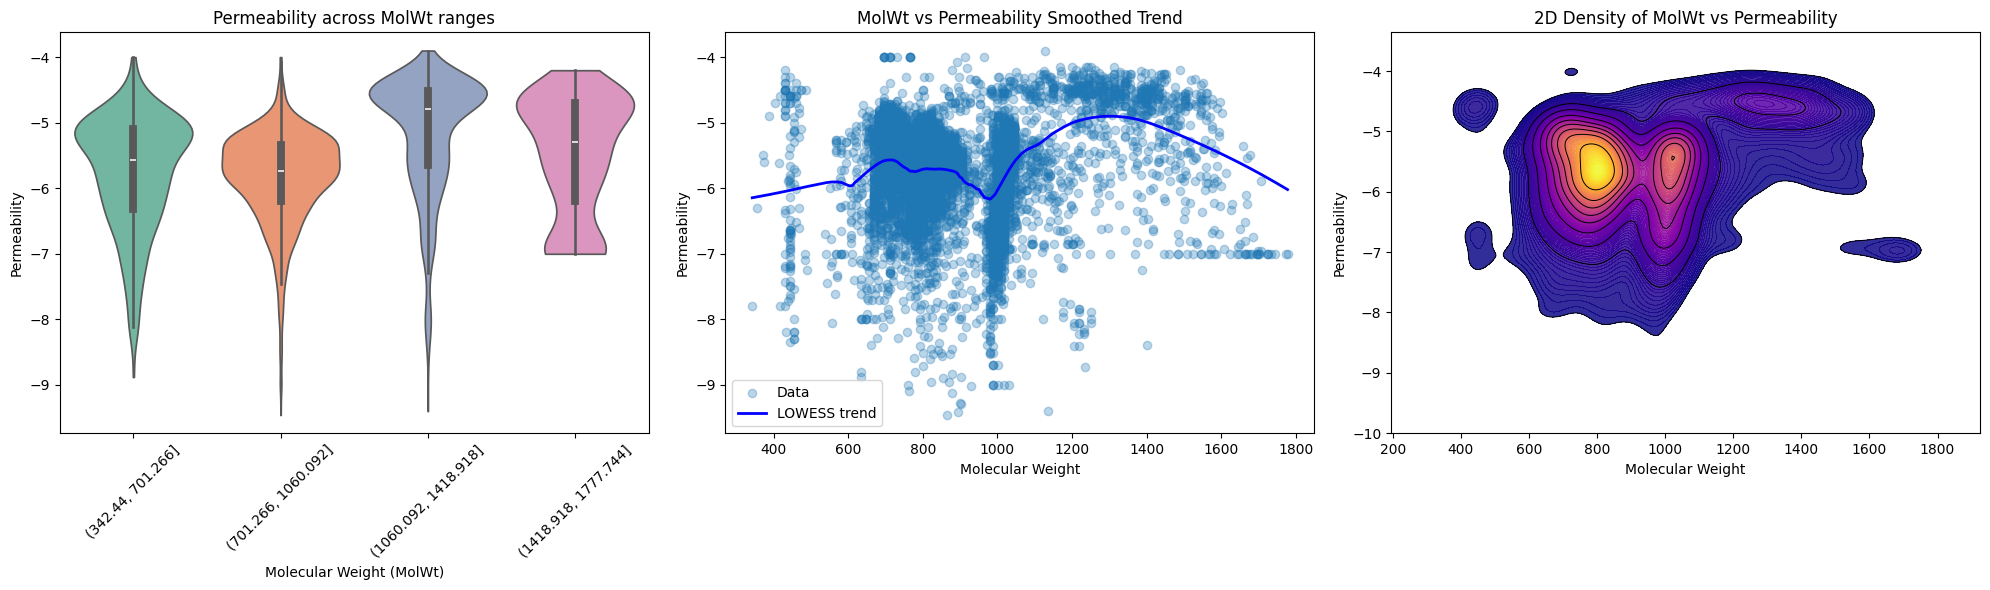

In [52]:
df_sorted = df.sort_values("MolWt")
bins = np.linspace(df["MolWt"].min(), df["MolWt"].max(), 5)  # 4 equal-width bins
df_sorted["MolWt_bin"] = pd.cut(df_sorted["MolWt"], bins=bins)

lowess_smoothed = lowess(df_sorted["Permeability"], df_sorted["MolWt"], frac=0.3)
x_smooth, y_smooth = lowess_smoothed[:, 0], lowess_smoothed[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Violin plot with 4 MolWt ranges
sns.violinplot(
    x="MolWt_bin", y="Permeability",
    data=df_sorted, palette="Set2", inner="box", ax=axes[0], cut=0
)
axes[0].set_title("Permeability across MolWt ranges")
axes[0].set_xlabel("Molecular Weight (MolWt)")
axes[0].set_ylabel("Permeability")
axes[0].tick_params(axis='x', rotation=45)

# LOWESS smoothed trend
axes[1].scatter(df_sorted["MolWt"], df_sorted["Permeability"], alpha=0.3, label="Data")
axes[1].plot(x_smooth, y_smooth, color="blue", linewidth=2, label="LOWESS trend")
axes[1].set_title("MolWt vs Permeability Smoothed Trend")
axes[1].set_xlabel("Molecular Weight")
axes[1].set_ylabel("Permeability")
axes[1].legend()

# 2D Density heatmap + contour
sns.kdeplot(
    x="MolWt", y="Permeability", data=df_sorted,
    fill=True, cmap="plasma", thresh=0.05, levels=100, ax=axes[2], alpha=0.85
)
sns.kdeplot(
    x="MolWt", y="Permeability", data=df_sorted,
    color="black", linewidths=0.7, ax=axes[2]
)
axes[2].set_title("2D Density of MolWt vs Permeability")
axes[2].set_xlabel("Molecular Weight")
axes[2].set_ylabel("Permeability")

plt.tight_layout()
plt.savefig("MolWt_vs_Permeability_Distribution_Trend_Density.png", dpi=600, bbox_inches="tight")
plt.show()


In [53]:
df_sorted = df.sort_values("MolWt")
bins = np.linspace(df["MolWt"].min(), df["MolWt"].max(), 5)  # 4 equal-width bins
df_sorted["MolWt_bin"] = pd.cut(df_sorted["MolWt"], bins=bins)
plt.figure(figsize=(8, 6))
sns.violinplot(
    x="MolWt_bin", y="Permeability",
    data=df_sorted, palette="Set2", inner="box", cut=0
)
plt.title("Permeability across MolWt ranges")
plt.xlabel("Molecular Weight (MolWt)")
plt.ylabel("Permeability")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("MolWt_vs_Permeability_Violin.png", dpi=600, bbox_inches="tight")
plt.close()

/tmp/ipykernel_3945542/3152878775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
